In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("/home/mengelsl/MA-bench-framework/eigen/outputs/benchmark_20251213_194838/benchmark_results.csv")

In [2]:
# Aggregation der Daten: Median der Metriken pro Algorithmus und Kernanzahl
df_agg = df.groupby(['cores', 'algorithm']).median().reset_index()

# IPC berechnen
df_agg["IPC"] = df_agg["instructions"] / df_agg["cycles"]

# Speedup relativ zu 1 Core
df_agg["speedup"] = df_agg.apply(
    lambda row: df_agg[(df_agg['cores'] == 1) & (df_agg['algorithm'] == row['algorithm'])]['task_duration_ms'].values[0] / row['task_duration_ms'],
    axis=1
)

df_agg["cache_miss_rate"] = df_agg["cache_misses"] / df_agg["cache_refs"]

df_agg.head()

,cores,algorithm,run,task_duration_ms,cycles,instructions,cache_refs,cache_misses,cpu_migrations,context_switches,IPC,speedup,cache_miss_rate
0,1,LANCZOS,3.0,169.62,6.257469e+08,8.348224e+08,45717730.0,7677098.0,0.0,59.0,1.334121,1.000000,0.167924
1,1,LOBPCG,3.0,260.84,9.627079e+08,1.900291e+09,109536345.0,11567793.0,0.0,61.0,1.973902,1.000000,0.105607
2,1,RQI,3.0,980.30,3.620709e+09,6.246761e+09,833254043.0,18349248.0,0.0,57.0,1.725287,1.000000,0.022021
3,2,LANCZOS,3.0,176.42,6.507936e+08,8.367503e+08,46001811.0,7766836.0,0.0,61.0,1.285738,0.961456,0.168838
4,2,LOBPCG,3.0,330.54,1.220180e+09,1.769565e+09,99619126.0,10817885.0,0.0,62.0,1.450249,0.789133,0.108592


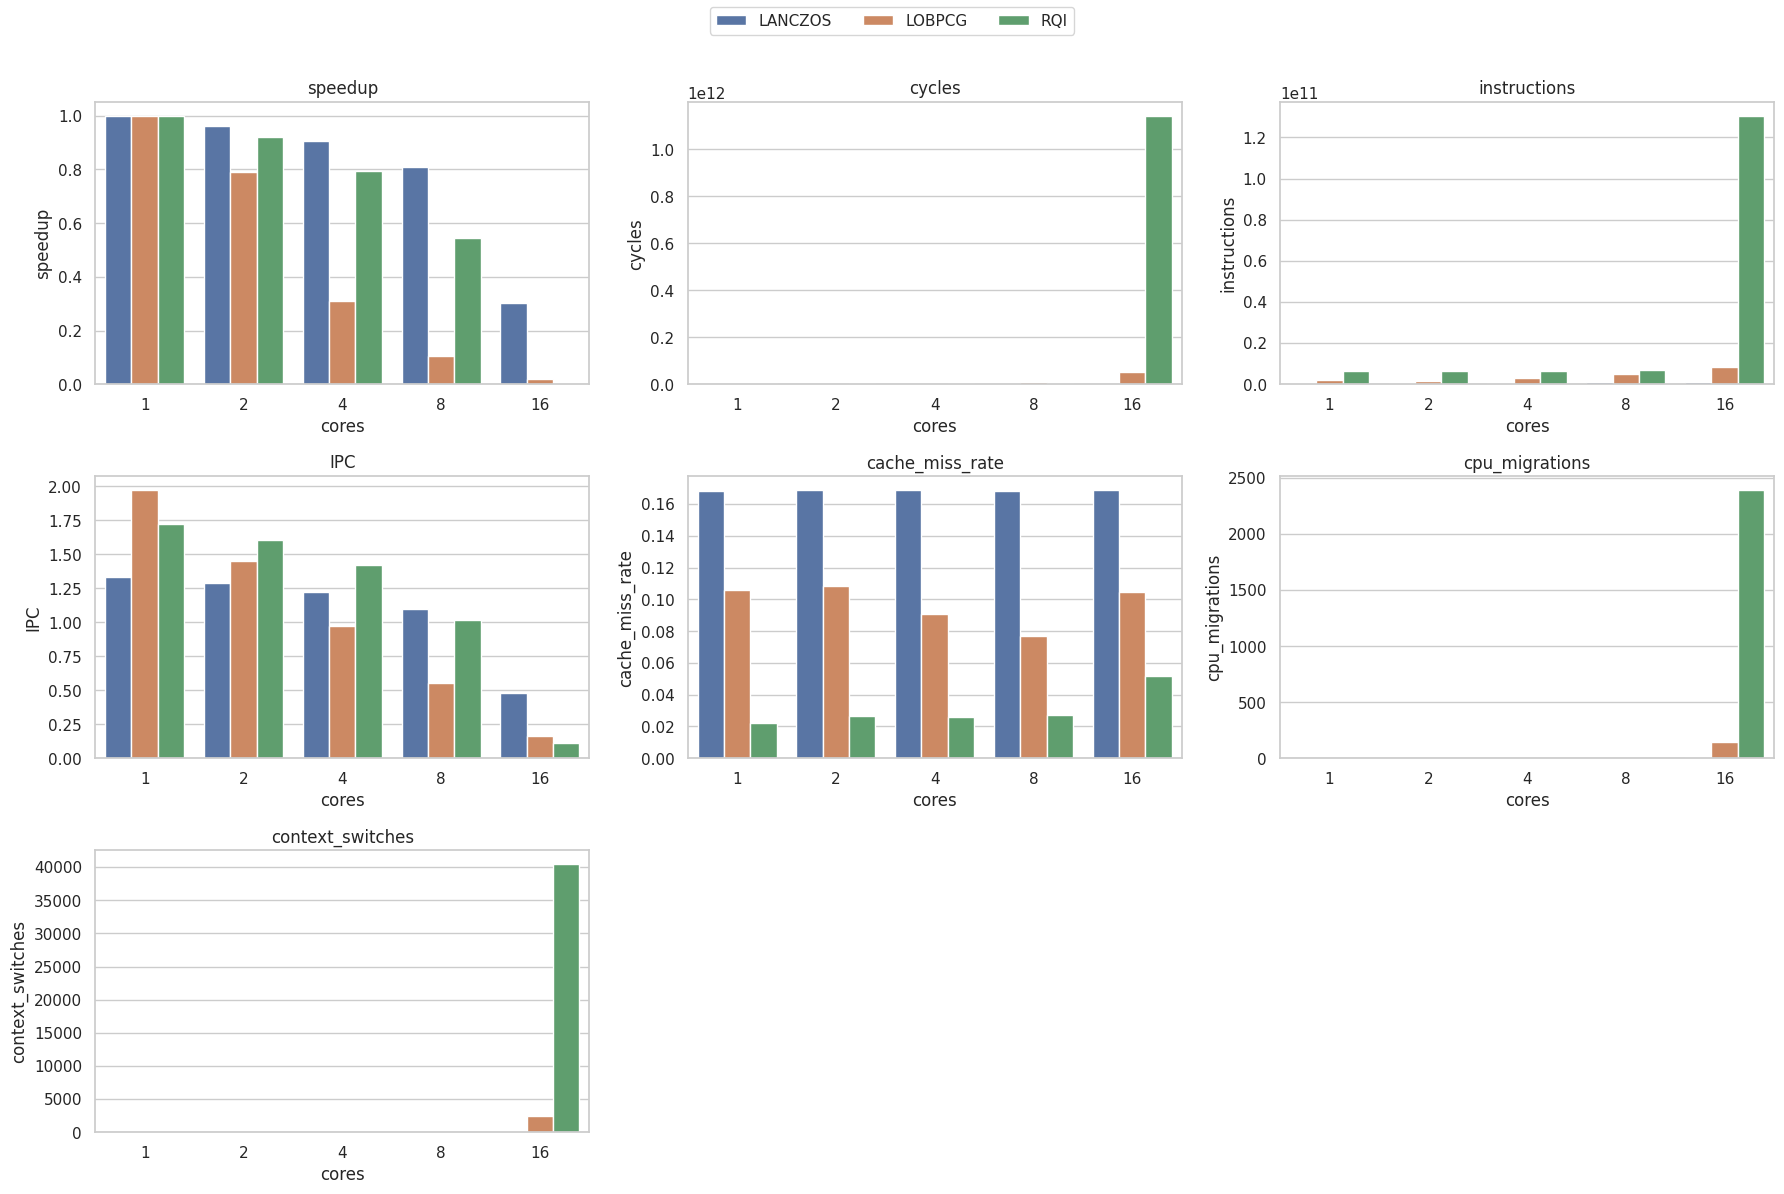

In [3]:
metrics = [
    "speedup",
    "cycles",
    "instructions",
    "IPC",
    "cache_miss_rate",
    "cpu_migrations",
    "context_switches",
]

ncols = 3
nrows = (len(metrics) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=df_agg,
        x="cores",
        y=metric,
        hue="algorithm",
        ax=ax,
    )
    ax.set_title(metric)
    ax.legend_.remove()  # sonst wird’s legend-spam

# eine gemeinsame Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

# leere Subplots killen
for ax in axes[len(metrics):]:
    ax.remove()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [100]:
df_agg[["algorithm","cores","Speedup"]]

,algorithm,cores,Speedup
0,LANCZOS,1,1.000000
1,LOBPCG,1,1.000000
2,RQI,1,1.000000
3,LANCZOS,2,0.961456
4,LOBPCG,2,0.789133
5,RQI,2,0.919744
6,LANCZOS,4,0.906865
7,LOBPCG,4,0.311767
8,RQI,4,0.795433
9,LANCZOS,8,0.808061
